In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [13]:
round(df['Churn'].mean() * 100, 1)

np.float64(26.6)

In [14]:
df.groupby('Contract')['Churn'].mean()

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64

In [15]:
df.groupby('PaymentMethod')['Churn'].mean()

PaymentMethod
Bank transfer (automatic)    0.167315
Credit card (automatic)      0.152531
Electronic check             0.452854
Mailed check                 0.192020
Name: Churn, dtype: float64

In [16]:
df.groupby('InternetService')['Churn'].mean()

InternetService
DSL            0.189983
Fiber optic    0.418928
No             0.074342
Name: Churn, dtype: float64

In [17]:
df.groupby('SeniorCitizen')['Churn'].mean()

SeniorCitizen
0    0.236503
1    0.416813
Name: Churn, dtype: float64

In [18]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-12','13-24','25-48','49-72'])
df.groupby('TenureGroup')['Churn'].mean()

TenureGroup
0-12     0.476782
13-24    0.287109
25-48    0.203890
49-72    0.095132
Name: Churn, dtype: float64

In [21]:
threshold = df['MonthlyCharges'].median()
threshold

np.float64(70.35)

In [22]:
df['HighCharge'] = np.where(
    df['MonthlyCharges'] > threshold,
    'High','Low')

In [23]:
df['HighCharge'].value_counts()

HighCharge
Low     3519
High    3513
Name: count, dtype: int64

In [24]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

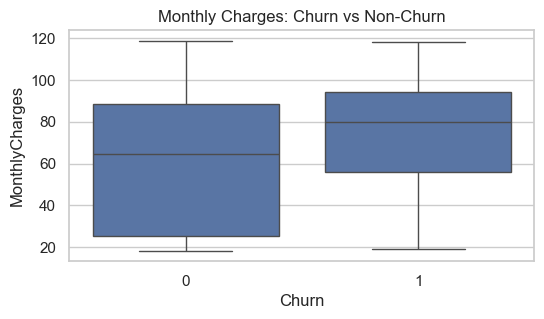

In [26]:
plt.figure(figsize=(6,3))
sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges')
plt.title("Monthly Charges: Churn vs Non-Churn")
plt.show()

In [29]:
risk_profiles = df.groupby(
['Contract', 'InternetService', 'PaymentMethod']
)['Churn'].mean().sort_values(ascending=False)
risk_profiles.head(3)

Contract        InternetService  PaymentMethod            
Month-to-month  Fiber optic      Electronic check             0.603673
                                 Mailed check                 0.507463
                                 Bank transfer (automatic)    0.455657
Name: Churn, dtype: float64

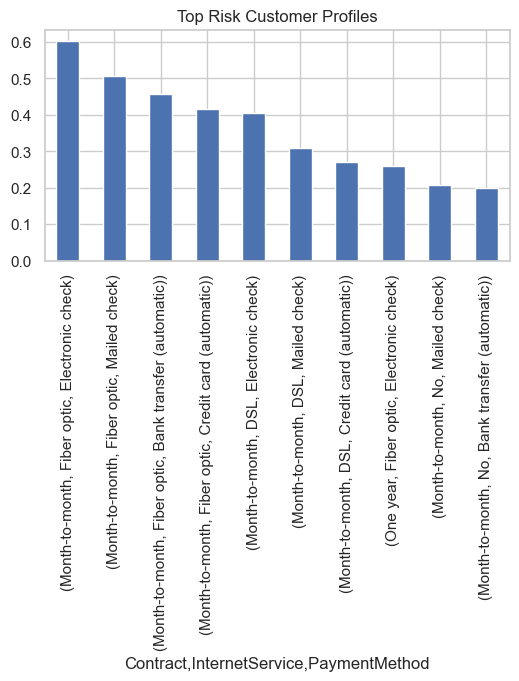

In [31]:
top_risk = risk_profiles.head(10)
top_risk.plot(kind='bar', figsize=(6,3))
plt.title("Top Risk Customer Profiles")
plt.show()

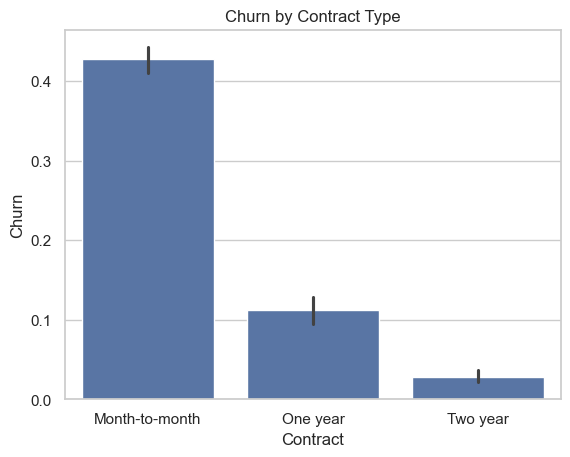

In [32]:
sns.barplot(data=df, x='Contract', y='Churn')
plt.title("Churn by Contract Type")
plt.show()

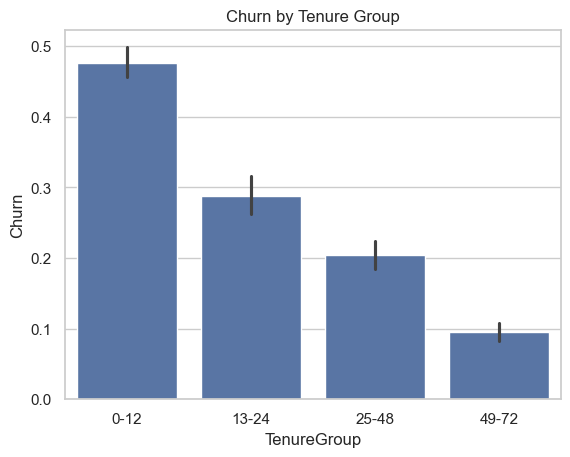

In [33]:
df['TenureGroup'] = pd.cut(df['tenure'], [0,12,24,48,72], labels=['0-12','13-24','25-48','49-72'])
sns.barplot(data=df, x='TenureGroup', y='Churn')
plt.title("Churn by Tenure Group")
plt.show()

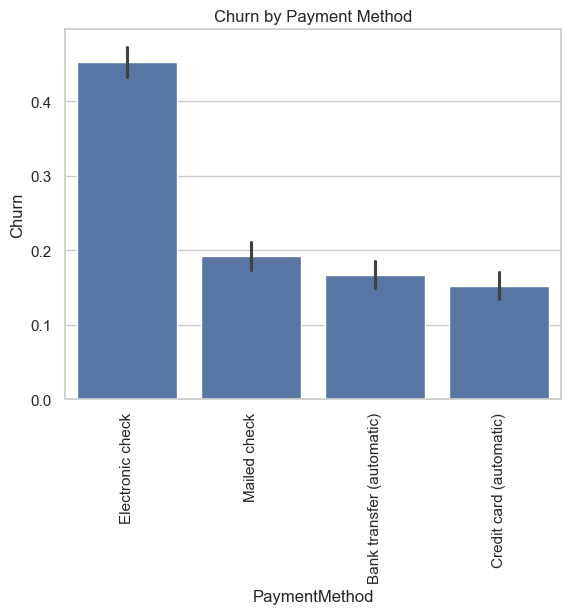

In [35]:
sns.barplot(data=df, x='PaymentMethod', y='Churn')
plt.xticks(rotation=90)
plt.title("Churn by Payment Method")
plt.show()

In [ ]:
ct = df.groupby(['Contract', 'InternetService'])['Churn'].mean().unstack() #bonus

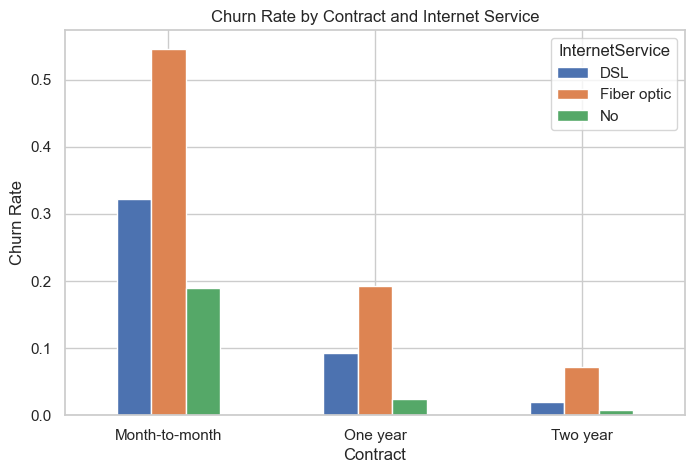

In [39]:
ct.plot(kind='bar', figsize=(8,5))
plt.title("Churn Rate by Contract and Internet Service")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df.groupby('Churn')['tenure'].mean() #bonus

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

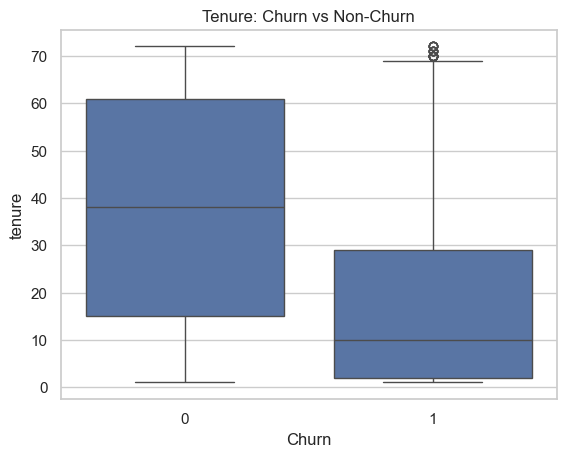

In [41]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title("Tenure: Churn vs Non-Churn")
plt.show()